EVA VWLS method for AMAS Project, based on https://doi.org/10.1016/j.hydroa.2018.100012

original code by peter resch, 12.3.2026

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
from iminuit import Minuit, cost
from scipy.stats import genextreme
import os

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

save_figures = False
verbose=False

## #read in file

Filepath: data/gev-mu=70,alpha=10,gamma=0.3,N=100.csv
Number of extreme values: 100


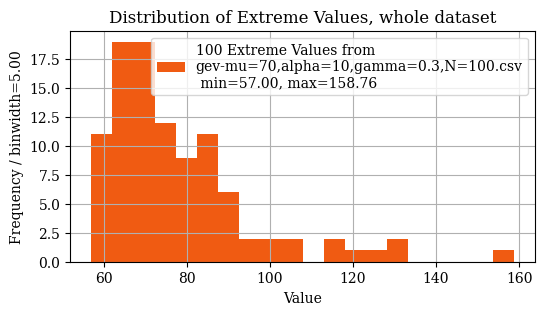

In [151]:
"""dataset location"""
filename="gev-mu=70,alpha=10,gamma=0.3,N=100.csv"
directory = "data"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")


"""read the values from the text file"""
extreme_values_from_file = []
with open(filepath, "r") as f:
    for line in f:
        extreme_values_from_file.append(float(line.strip()))

print(f"Number of extreme values: {len(extreme_values_from_file)}")



"""illustrating the distribution of the extreme values with a histogram"""
min_value = min(extreme_values_from_file)
max_value = max(extreme_values_from_file)
#n_bins = 50
bin_width = 5
n_bins = int((max_value - min_value) / bin_width)

plt.hist(extreme_values_from_file, bins=n_bins, alpha=1, color=my_cmap(0.8),label=f"{len(extreme_values_from_file)} Extreme Values from\n{filename}\n min={min_value:.2f}, max={max_value:.2f}")
plt.xlabel("Value")
plt.ylabel(f"Frequency / binwidth={bin_width:.2f}")
plt.title("Distribution of Extreme Values, whole dataset")
plt.grid()
plt.legend()
plt.show()

if save_figures:
    plt.savefig(f"{directory}/histogram_extreme_values_{filename}.png")

## #Selecting Distribution and estimating start parameters

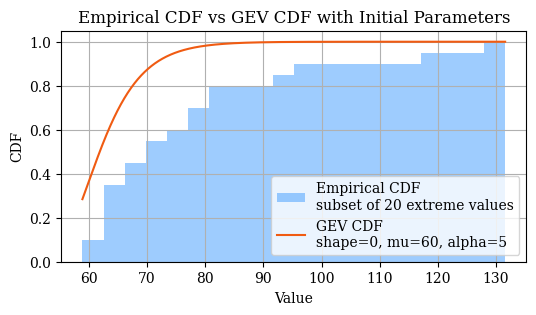

In [152]:
"""define starting parameters for fitting the GEV distribution"""

shape_starting = 0
mu_starting = 60
alpha_starting = 5

def gev_cdf(xi_array, shape_param, mu_param, alpha_param):
    cdf_value=stats.genextreme.cdf(x=xi_array, c=shape_param, loc=mu_param, scale=alpha_param)
    if verbose:
        print(f"GEV CDF at xi={xi_array:.4f}: {cdf_value:.8e}")
    return cdf_value


"""select a subset of the extreme values for fitting the GEV distribution"""
subset_size = 20
x_subset=extreme_values_from_file[:subset_size]


"""plotting the empirical CDF of the subset of extreme values and the GEV CDF with the initial parameters"""
xi_values_plot = np.linspace(min(x_subset), max(x_subset), 1000)
gev_cdf_values = gev_cdf(xi_values_plot, shape_starting, mu_starting, alpha_starting)

plt.hist(x_subset, bins=n_bins, density=True, alpha=0.5, color=my_cmap(0.2), label=f"Empirical CDF\nsubset of {subset_size} extreme values",cumulative=True)
plt.plot(xi_values_plot, gev_cdf_values, label=f"GEV CDF\nshape={shape_starting}, mu={mu_starting}, alpha={alpha_starting}", color=my_cmap(0.8))
plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical CDF vs GEV CDF with Initial Parameters")
plt.grid()
plt.legend()
plt.show()
if save_figures:
    plt.savefig(f"{directory}/empirical_cdf_vs_gev_cdf_initial_{filename}.png")

## #Weibull Plotting Positions

In [153]:
"""Ranking the subset of data points"""
x_m = np.sort(x_subset)
m_array = np.arange(1, subset_size + 1)  # ranks from 1 to subset_size


"""define Weibull plotting positions"""
def weibull_p_m(rank_m, n):
    """ rank_m >= 1
        n = number of data points in the subset"""
    p_m=rank_m / (n + 1)
    #print(f"P(m={rank_m},N={n}) = {p_m:.8f}")
    return p_m


"""best estimate for xi_m in the given search range"""
def first_estimate_xi(rank_m,search_min,search_max,shape_param, mu_param, alpha_param):
    """returns  -1 if search_min is too high
                +1 if search_max is too low
                proposed xi_m and stepsize if the search range contains the solution"""
    if rank_m < 1 or rank_m > subset_size:
        raise ValueError(f"rank_m must be between 1 and {subset_size}, got {rank_m}.")
    
    p_m=weibull_p_m(rank_m, subset_size)
    f_min = gev_cdf(search_min, shape_param, mu_param, alpha_param)
    f_max = gev_cdf(search_max, shape_param, mu_param, alpha_param)
    #print(f_max)
    if f_min > p_m:
        #print(f"GEV CDF at search_min={search_min:.4f} is {f_min}: greater than p_m={p_m:.6f} for rank {rank_m}. Consider decreasing search_min.")
        return -1
    elif f_max < p_m:
        #print(f"GEV CDF at search_max={search_max:.4f} is {f_max}: less than p_m={p_m:.6f} for rank {rank_m}. Consider increasing search_max.")
        return +1
    
    else:
        diff = (search_max - search_min)
        if diff <= 0:
            print(f"rank_m={rank_m}: diff={diff}")
            raise ValueError("search_max must be greater than search_min.")
        
        steps=100
        stepsize = diff / steps
        xi_proposal = np.arange(search_min, search_max, stepsize)

        for m in range(steps):
            gev_cdf_value = gev_cdf(xi_proposal[m], shape_param, mu_param, alpha_param)
            #print(f"xi_proposal: {xi_proposal[m]:.4f}, GEV CDF: {gev_cdf_value:.6f}, p_m: {p_m:.6f}")
            if gev_cdf_value >= p_m:
                #print(f"Found corresponding xi_m in the proposal array")
                return xi_proposal[m],stepsize
        return search_max,stepsize# between last proposal and search_max, the solution must lie



"""best estimate for xi_m in the search range with a given resolution of decimal places """
def best_estimate_xi_with_resolution(rank_m,search_min,search_max,shape_param, mu_param, alpha_param,resolution=0.01):
    while True:
        result = first_estimate_xi(rank_m, search_min, search_max,shape_param, mu_param, alpha_param)
        if verbose:
            print(f"in best_estimate loop: first_estimate result={result}")
        if result == -1:
            # shift range downward
            range = search_max - search_min
            search_min -= range
            search_max -= range
            continue

        if result == 1:
            # shift range upward
            range = search_max - search_min
            search_min += range
            search_max += range
            continue

        # Here result is guaranteed to be a tuple (xi_propose, step_size)
        xi_propose, step_size = result

        if step_size <= resolution:
            return xi_propose

        # refine around candidate
        search_max = xi_propose
        search_min = xi_propose - step_size

In [154]:

#testing
#rank_m =3
#result = first_estimate_xi(rank_m, 0, 13,shape_starting, mu_starting, alpha_starting)
#if result == (1 or -1):
#    raise ValueError(f"best_estimate_xi returned None for rank_m={rank_m} in range [{x_m[0]:.4f}, {x_m[-1]:.4f}]")
#xi_value, xi_in_range = result

#print(f"cdf(m={rank_m}) = {gev_cdf(xi_value, shape_starting, mu_starting, alpha_starting):.8f}")
#print(f"xi(m={rank_m}) = {xi_value:.4f}")
#print(f"P(m={rank_m},N={subset_size}) = {weibull_p_m(rank_m, subset_size):.8f}")
#print(f"x(m={rank_m}) = {x_m[rank_m]:.4f}")
#print(f"Difference between GEV CDF at xi_m and Weibull plotting position: {gev_cdf(xi_value, shape_starting, mu_starting, alpha_starting) - weibull_p_m(rank_m, subset_size):.8f}")

best_estimate_xi_with_resolution(rank_m, 13, 14,shape_starting, mu_starting, alpha_starting, resolution=0.001)

np.float64(56.67139999999991)

In [155]:
gex.ppf(weibull_p_m(rank_m, subset_size), shape_starting, loc=mu_starting, scale=alpha_starting)

np.float64(56.67135094710862)

In [156]:
def round_partial(value, resolution):
    return np.round(value / resolution) * resolution


def find_all_xi_m(ranked_m,estimate_search_min,estimate_search_max,shape_param, mu_param, alpha_param,res=0.0001):
    xi_m=np.zeros_like(ranked_m, dtype=float)
    for i,rank in enumerate(ranked_m):#rank in [1, subset_size]
        #print(f"in find_all_xi_m: rank{rank}")
        if i==0:
            xi_m[0] = round_partial(best_estimate_xi_with_resolution(1, estimate_search_min, estimate_search_max,shape_param, mu_param, alpha_param,res),res)
            continue
        estimate=best_estimate_xi_with_resolution(rank, xi_m[i-1], xi_m[i-1]+2,shape_param, mu_param, alpha_param,res)
        xi_m[i] = round_partial(estimate,res)

        if verbose:
            print(f"Calculated xi_m for rank {rank}/{subset_size}", end="\r")
    
    xi_m = np.array(xi_m)
    return xi_m


def find_all_xi_m_exact(ranked_m,shape_param, mu_param, alpha_param):
    xi_m=gex.ppf(weibull_p_m(ranked_m, subset_size), -shape_param, loc=mu_param, scale=alpha_param)
    return xi_m

In [157]:
"""calculating plotting positions and corresponding xi_m for the ranked data points"""
ranks_m = np.arange(1, subset_size + 1)
p_m = weibull_p_m(ranks_m, n=subset_size)

xi_m = find_all_xi_m_exact(ranks_m,10,15,shape_starting, mu_starting, alpha_starting, res=0.001)

TypeError: find_all_xi_m_exact() got an unexpected keyword argument 'res'

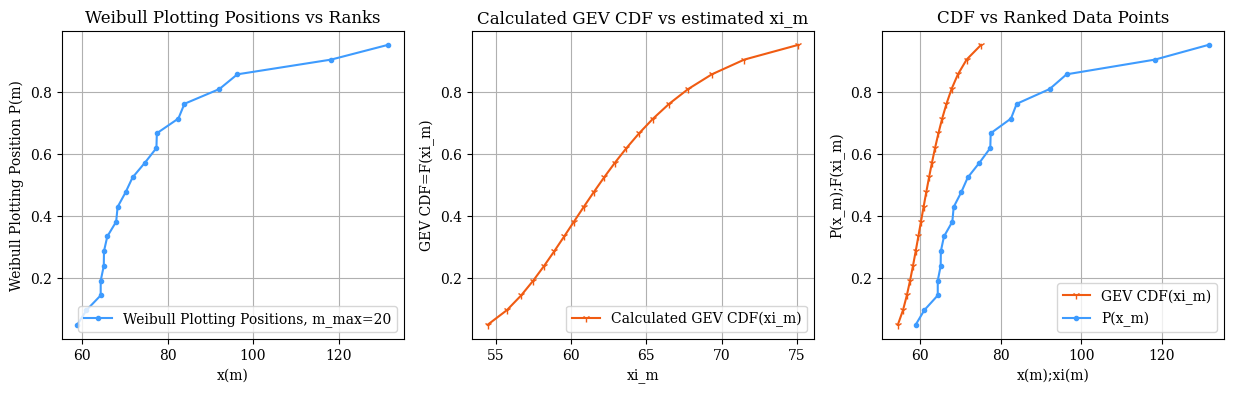

In [158]:
"""Illustrating the ranked data points and their Weibull plotting positions"""
fig,[ax_weibull,ax_cdf,ax_combi]=plt.subplots(1,3,figsize=(15,4))

ax_weibull.plot(x_m, p_m, color=my_cmap(0.2), label=f"Weibull Plotting Positions, m_max={subset_size}", marker='.', linestyle='-')
ax_weibull.set_xlabel("x(m)")
ax_weibull.set_ylabel("Weibull Plotting Position P(m)")
ax_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_weibull.grid()
ax_weibull.legend(loc="lower right")


ax_cdf.plot(xi_m,gev_cdf(xi_m,shape_starting,mu_starting,alpha_starting), color=my_cmap(0.8), label="Calculated GEV CDF(xi_m)", marker=my_marker, linestyle='-')
ax_cdf.set_xlabel("xi_m")
ax_cdf.set_ylabel("GEV CDF=F(xi_m)")
ax_cdf.set_title("Calculated GEV CDF vs estimated xi_m")
ax_cdf.grid()
ax_cdf.legend(loc="lower right")

ax_combi.plot(xi_m,gev_cdf(xi_m,shape_starting,mu_starting,alpha_starting), color=my_cmap(0.8), label="GEV CDF(xi_m)", marker=my_marker, linestyle='-')
ax_combi.plot(x_m, p_m, color=my_cmap(0.2), label=f"P(x_m)", marker='.', linestyle='-')
ax_combi.set_xlabel("x(m);xi(m)")
ax_combi.set_ylabel("P(x_m);F(xi_m)")
ax_combi.set_title("CDF vs Ranked Data Points")
ax_combi.grid()
ax_combi.legend(loc="lower right")

if save_figures:
     plt.savefig(f"{directory}/xi_m_and_weibull_plotting_positions_{filename}.png")


## #Weighing and fitting - functions

In [159]:
def gev_pdf(xi_array, shape_param, mu_param, alpha_param):
    pdf_value=stats.genextreme.pdf(x=xi_array, c=shape_param, loc=mu_param, scale=alpha_param)
    if verbose:
        print(f"GEV PDF at xi={xi_array:.4f}: {pdf_value:.8e}")
    return pdf_value


def g_fct(rank,n_data_points):
    g=scipy.special.comb(N=n_data_points, k=rank, exact=True)/rank
    if verbose:
        print(f"g(rank={rank}, n_data_points={n_data_points}): {g:.8e}")
    return g


def pdf_of_xi_m(rank,n_data_points, xi_m,shape_param, mu_param, alpha_param):
    g_value=g_fct(rank, n_data_points)
    gev_cdf_value = gev_cdf(xi_m, shape_param, mu_param, alpha_param)
    gev_pdf_value = gev_pdf(xi_m, shape_param, mu_param, alpha_param)
    f_m=g_value * gev_cdf_value**(rank-1) * (1-gev_cdf_value)**(n_data_points-rank)*gev_pdf_value
    if verbose:
        print(f"pdf_of_xi_m for rank {rank} at xi_m={xi_m:.4f}: {f_m:.8e}")
    return f_m


def xi_m_mean(rank,n_data_points,shape_param, mu_param, alpha_param):
    integral = scipy.integrate.quad(lambda xi: xi * pdf_of_xi_m(rank,n_data_points, xi,shape_param, mu_param, alpha_param), -np.inf, np.inf)
    if verbose:
        print(f"xi_mean for rank {rank}: {integral}")
    return integral[0]

    
def xi_m_variance(rank,n_data_points,shape_param, mu_param, alpha_param):
    mean_xi_m=xi_m_mean(rank,n_data_points,shape_param, mu_param, alpha_param)
    integral = scipy.integrate.quad(lambda xi: (xi-mean_xi_m)**2 * pdf_of_xi_m(rank,n_data_points, xi,shape_param, mu_param, alpha_param), -np.inf, np.inf)
    if verbose:
        print(f"xi_variance for rank {rank}: {integral}")
    return integral[0]


def calculating_weights(rank,shape_param, mu_param, alpha_param):
    xi_m_variance_value=xi_m_variance(rank, subset_size,shape_param, mu_param, alpha_param)
    weight=1/xi_m_variance_value
    if verbose:
        print(f"Weight for rank {rank}: {weight}")
    return weight


def calculate_all_weights(rank_array,shape_param, mu_param, alpha_param):
    weights=np.zeros_like(rank_array, dtype=float)
    for i,rank in enumerate(rank_array):
        weights[i]=calculating_weights(rank,shape_param, mu_param, alpha_param)
        print(f"Calculated weight for rank {rank}/{subset_size}", end="\r")
    return weights


def sum_of_weights(weight_array):
    total_weight=np.sum(weight_array)
    print(f"Total weight: {total_weight}")
    return total_weight


def normalize_weights(weight_array):
    sum=sum_of_weights(weight_array)
    #print(f"normalized")
    return weight_array/sum


In [160]:
#test

#verbose=True
rank_test=1
xi_1=xi_m[rank_test-1]

print(f"Testing the functions for rank {rank_test}, subset length={subset_size}")

#gev_cdf_1=gev_cdf(xi_1, shape_param, mu_param, alpha_param)
#gev_pdf_1=gev_pdf(xi_1, shape_param, mu_param, alpha_param)
#g_fct_1=g_fct(rank_test, subset_size)
#pdf_xi_1=pdf_of_xi_m(rank_test, subset_size, xi_1)
#xi_1_mean=xi_m_mean(rank_test, subset_size)
#xi_1_variance=xi_m_variance(rank_test, subset_size)
#weight_1=calculating_weights(rank_test)

Testing the functions for rank 1, subset length=20


## #Reject data - function

In [161]:
def reject_first_maskvalue(xi_array, b_parameter=0.001):
    """
    Tests wether the first rank of the array should be rejected

    Raises Error, if the array is too small, or entries are not useable

    xi_array (np.array): Array of ranked xi values.

    b_parameter (float): Selected rejection test parameter.
    
    Returns:
        bool
            True: if it should be kept.

            False: rank_k (k=1) should be rejected.
    """
    if len(xi_array)<5:
        raise ValueError("xi_array must have at least 5 elements to perform the rejection test. Data is unreliable.")
    xi_k=xi_array[0]
    xi_k_plus_1=xi_array[1]
    xi_n=xi_array[-1]
    if (xi_n-xi_k)<=0:
        raise ValueError("Either array not sorted or the entries are zero or the entries are all equal")
    test_value=(xi_k_plus_1-xi_k)/(xi_n-xi_k)
    if test_value<b_parameter:
        #reject rank_k
        return False
    else:
        #keep rank_k
        return True



def rejection_mask_procedure(xi_array, b_parameter=0.001):
    """
    goes through the array and tests, if ranks should be rejected

    Returns:
        array(bool): mask the rejected data - False=Rejected
    """
    rejection_mask=np.full_like(xi_array, True, dtype=bool)
    for k in range(len(xi_array)):
        masked_array=xi_array[rejection_mask]
        #print(f"k:{k}; ")
        if reject_first_maskvalue(masked_array, b_parameter) == False:
            #print(f"masked array:{masked_array}")
            rejection_mask[k] = False
    return rejection_mask

In [162]:
#testing
xi_m_test=np.array(xi_m)
array=np.ones((10))
array[4]=5
array[-1]=10
#print(array)
reject_mask=rejection_mask_procedure(array)
print(f"reject: {reject_mask}")

reject: [False False False  True  True  True  True  True  True  True]


# Fitting process

## Init (0)

In [165]:
"""fitting xi_m to x_m"""

ranks_m= ranks_m
xi_m=xi_m
x_m=x_m
weights_array=np.full_like(xi_m,1/len(xi_m))

shape_starting=shape_starting
mu_starting=mu_starting
alpha_starting=alpha_starting

print(f"Starting parameters for fitting: shape={shape_starting}, mu={mu_starting}, alpha={alpha_starting}")



def calc_minimum(ranks_m, xi_array, x_array, weights_array,shape_param, mu_param, alpha_param):
    s=0
    xi_array=find_all_xi_m_exact(ranks_m,shape_param, mu_param, alpha_param)
    s=np.sum(weights_array * (xi_array - x_array)**2)
    return s


def objective_3p(*args: float) -> float:
    shape_param, mu_param, alpha_param = args
    return calc_minimum(ranks_m, xi_m, x_m, weights_array, shape_param, mu_param, alpha_param)


mfit = Minuit(
    objective_3p,
    shape_starting,
    mu_starting,
    alpha_starting,
    name=("shape_param", "mu_param", "alpha_param"),
)
mfit.migrad(ncall=10)

Starting parameters for fitting: shape=0, mu=60, alpha=5


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 111.9                      │              Nfcn = 28               │
│ EDM = 61.8 (Goal: 0.0002)        │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           ABOVE call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name        │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ shape_param │   1.000   │   0.018   │            │            │         │         │       │
│ 1 │ mu_param    │    60     │     1     │            │            │         │         │       │
│ 2 │ alpha_param │    5.0    │    0.2    │            │            │         │         │       │
└───┴─────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────────┬─────────────────────────────────────┐
│             │ shape_param    mu_param alpha_param │
├─────────────┼─────────────────────────────────────┤
│ shape_param │    0.000322           0           0 │
│    mu_param │           0           1        0.00 │
│ alpha_param │           0        0.00      0.0383 │
└─────────────┴─────────────────────────────────────┘

## Process starts iteratively

In [166]:
iterations=20
parameter_iteration_array=np.zeros((iterations,3), dtype=float)

parameter_iteration_array[0][0]=mfit.values._get(0)
parameter_iteration_array[0][1]=mfit.values._get(1)
parameter_iteration_array[0][2]=mfit.values._get(2)

rej_mask=np.full_like(xi_m, True, dtype=bool)

for i in range(1,iterations):
    print(f"Iteration {i}/{iterations}")
    shape=mfit.values["shape_param"]
    mu=mfit.values["mu_param"]
    alpha=mfit.values["alpha_param"]

    xi_m=find_all_xi_m_exact(ranks_m[rej_mask],shape, mu, alpha)

    try:
        rej_mask=rejection_mask_procedure(xi_m[rej_mask], b_parameter=0.001)
        print(f"{rej_mask} items rejected in iteration {i}.")
    except ValueError as e:        print(f"Error in rejection procedure at iteration {i}: {e}")

    weights_array=calculate_all_weights(ranks_m[rej_mask],shape, mu, alpha)
    weights_array=normalize_weights(weights_array)
    print(f"Calculated and normalized weights for iteration. {weights_array}")

    mfit = Minuit(
        objective_3p,
        shape,
        mu,
        alpha,
        name=("shape_param", "mu_param", "alpha_param"),
    )
    mfit.migrad(ncall=80)#50->50sec,100-> >9min

    parameter_iteration_array[i][0]=mfit.values._get(0)
    parameter_iteration_array[i][1]=mfit.values._get(1)
    parameter_iteration_array[i][2]=mfit.values._get(2)

    if parameter_iteration_array[i-1][0] == mfit.values["shape_param"] and parameter_iteration_array[i-1][1] == mfit.values["mu_param"] and parameter_iteration_array[i-1][2] == mfit.values["alpha_param"]:
        print(f"Convergence reached at iteration {i}.")
        break

Iteration 1/20
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True] items rejected in iteration 1.
Total weight: 9.117781582464732e+60
Calculated and normalized weights for iteration. [2.74848582e-63 2.85508988e-64 4.18877860e-64 6.31301912e-64
 6.12194851e-53 4.26092372e-50 3.60407132e-47 3.67540143e-44
 4.49667383e-41 6.58611051e-38 1.15554591e-34 2.43717842e-31
 6.22122082e-28 1.94295668e-24 7.54638868e-21 3.73500075e-17
 2.44557724e-13 2.25283320e-09 3.27571841e-05 9.99967241e-01]
Iteration 2/20
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True] items rejected in iteration 2.
Total weight: 2.066140282515246e+50
Calculated and normalized weights for iteration. [1.65711310e-52 1.80604875e-53 2.64032295e-53 3.96818741e-53
 5.64938750e-53 1.09395288e-42 2.73549659e-40 8.24699112e-38
 2.98284083e-35 1.29156317e-32 6.69918220e-30 4.17705173e-27
 3.

In [169]:

xi_m=find_all_xi_m_exact(ranks_m[rej_mask],shape, mu, alpha)

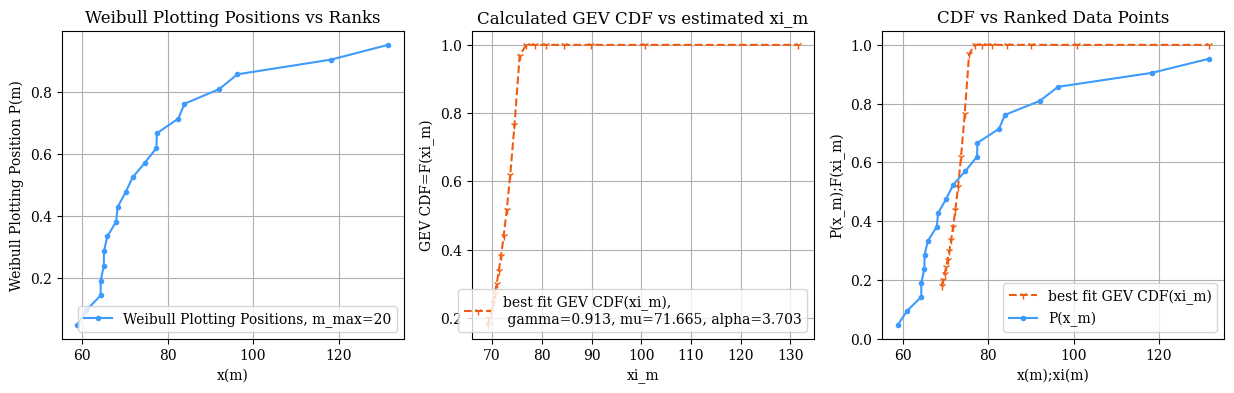

In [170]:
"""Illustrating the ranked data points and their Weibull plotting positions"""

fig_fit,[ax_fit_weibull,ax_fit_cdf,ax_fit_combi]=plt.subplots(1,3,figsize=(15,4))

ax_fit_weibull.plot(x_m[rej_mask], p_m[rej_mask], color=my_cmap(0.2), label=f"Weibull Plotting Positions, m_max={subset_size}", marker='.', linestyle='-')
ax_fit_weibull.set_xlabel("x(m)")
ax_fit_weibull.set_ylabel("Weibull Plotting Position P(m)")
ax_fit_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_fit_weibull.grid()
ax_fit_weibull.legend(loc="lower right")


ax_fit_cdf.plot(xi_m[rej_mask],gev_cdf(xi_m[rej_mask],mfit.values._get(0),mfit.values._get(1),mfit.values._get(2)), color=my_cmap(0.8), label=f"best fit GEV CDF(xi_m),\n gamma={mfit.values._get(0):.3f}, mu={mfit.values._get(1):.3f}, alpha={mfit.values._get(2):.3f}", marker=my_marker, linestyle='--')
ax_fit_cdf.set_xlabel("xi_m")
ax_fit_cdf.set_ylabel("GEV CDF=F(xi_m)")
ax_fit_cdf.set_title("Calculated GEV CDF vs estimated xi_m")
ax_fit_cdf.grid()
ax_fit_cdf.legend(loc="lower right")

ax_fit_combi.plot(xi_m[rej_mask],gev_cdf(xi_m[rej_mask],mfit.values._get(0),mfit.values._get(1),mfit.values._get(2)), color=my_cmap(0.8), label=f"best fit GEV CDF(xi_m)", marker=my_marker, linestyle='--')
ax_fit_combi.plot(x_m[rej_mask], p_m[rej_mask], color=my_cmap(0.2), label=f"P(x_m)", marker='.', linestyle='-')
ax_fit_combi.set_xlabel("x(m);xi(m)")
ax_fit_combi.set_ylabel("P(x_m);F(xi_m)")
ax_fit_combi.set_title("CDF vs Ranked Data Points")
ax_fit_combi.grid()
ax_fit_combi.legend(loc="lower right")

if save_figures:
     fig_fit.savefig(f"{directory}/xi_m_and_weibull_plotting_positions_{filename}.png")
